**01_eda.ipynb: Exploratory Data Analysis & Fraud Pattern Investigation**

**Multimodal Financial Fraud / Risk Detector**  
This notebook conducts the full Phase 2 exploratory data analysis and fraud pattern investigation on the IEEE-CIS dataset.  
All reusable ingestion and validation components are imported from `src.preprocessing`.

```
01_eda.ipynb
│
├── 1. Load dataset
├── 2. Dataset structure
├── 3. Target / fraud distribution
├── 4. Temporal distribution
├── 5. Missing-value analysis
├── 6. Categorical analysis
├── 7. Numerical analysis
├── 8. Fraud-specific patterns
├── 9. Leakage investigation
├── 10. Train/validation/test verification
└── 11. EDA conclusions
```


**1. Load Dataset**

We import required libraries and load the IEEE-CIS transaction and identity data using our memory-optimized `load_and_merge_data` pipeline from `src.preprocessing`.  
*Configuration*: `NROWS = 100_000` is used for responsive exploration (set to `None` to run the full 590,540 rows).


In [1]:
import sys
from pathlib import Path

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import (
    load_and_merge_data,
    validate_schema,
    get_feature_groups,
    compute_missing_and_cardinality,
    temporal_train_val_test_split
)

# Plotting configuration
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

FIG_DIR = PROJECT_ROOT / "results" / "figures"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

NROWS = 100_000  # Set to None for complete dataset run
data_dir = PROJECT_ROOT / "data" / "raw"

print(f"Loading merged dataset from {data_dir} (nrows={NROWS})...")
df = load_and_merge_data(data_dir=data_dir, split="train", nrows=NROWS, reduce_memory=True, verbose=True)


2026-09-30 23:10:38,351 - INFO - Loading train_transaction.csv (nrows=100000)...


Loading merged dataset from C:\Ongoing Projects\2026.09.30 Multimodal-Financial-Fraud-Detector\Multimodal-Financial-Fraud-Detector\data\raw (nrows=100000)...


2026-09-30 23:10:44,035 - INFO - Memory reduced from 300.60 MB to 155.16 MB (48.4% reduction)
2026-09-30 23:10:44,039 - INFO - Successfully loaded train_transaction.csv with shape: (100000, 394)
2026-09-30 23:10:44,040 - INFO - Loading train_identity.csv (nrows=100000)...
2026-09-30 23:10:44,608 - INFO - Memory reduced from 31.28 MB to 22.13 MB (29.3% reduction)
2026-09-30 23:10:44,609 - INFO - Successfully loaded train_identity.csv with shape: (100000, 41)
2026-09-30 23:10:44,616 - INFO - Merging train transaction (100000 rows) and identity (100000 rows) on TransactionID...
2026-09-30 23:10:45,017 - INFO - Merged dataset shape: (100000, 434). Identity match rate: 40.28% (40283/100000)


**2. Dataset Structure**

We validate the schema and group features into Target, Identifiers, Timestamps, Categorical, and Numerical features according to official IEEE-CIS domain documentation.


In [2]:
# Validate schema integrity
validation = validate_schema(df, split="train")
feature_groups = get_feature_groups(df)

target_col = feature_groups["target"][0]
id_col = feature_groups["id"][0]
time_col = feature_groups["timestamp"][0]
cat_cols = feature_groups["categorical"]
num_cols = feature_groups["numerical"]

print("=== Dataset Structure Summary ===")
print(f"Total Rows:            {len(df):,}")
print(f"Total Columns:         {len(df.columns)}")
print(f"Target Column:         '{target_col}'")
print(f"Primary Key:           '{id_col}'")
print(f"Timestamp Column:      '{time_col}'")
print(f"Categorical Features:  {len(cat_cols)}")
print(f"Numerical Features:    {len(num_cols)}")
print(f"RAM Footprint:         {validation['memory_mb']} MB")


2026-09-30 23:10:45,166 - INFO - --- Running Schema Validation for 'train' dataset ---
2026-09-30 23:10:45,179 - INFO - Target distribution: {0: 97439, 1: 2561} (Fraud rate: 2.56%)


=== Dataset Structure Summary ===
Total Rows:            100,000
Total Columns:         434
Target Column:         'isFraud'
Primary Key:           'TransactionID'
Timestamp Column:      'TransactionDT'
Categorical Features:  49
Numerical Features:    382
RAM Footprint:         176.91 MB


**3. Target / Fraud Distribution**

We analyze the base rate of fraud and class imbalance. In financial fraud detection, severe imbalance determines loss function choice (e.g. Weighted BCE with `pos_weight` or Focal Loss) and dictates the use of PR-AUC as the primary metric.


C:\Users\mst\AppData\Local\Temp\ipykernel_20088\4097711487.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=["Legitimate (0)", "Fraud (1)"], y=target_counts.values, palette=["#2ecc71", "#e74c3c"])


=== Target Distribution ===
Legitimate (0): 97,439 (97.44%)
Fraudulent (1): 2,561 (2.56%)
Class Imbalance Ratio: 38.05 : 1
Recommended BCE pos_weight: ~38.05


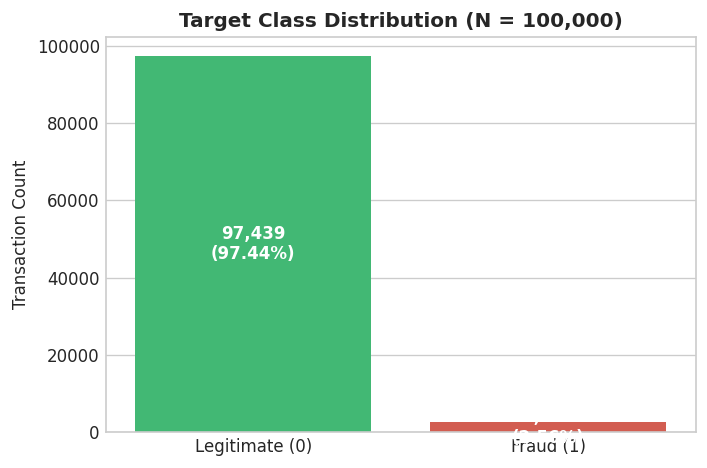

In [3]:
target_counts = df[target_col].value_counts()
target_pct = df[target_col].value_counts(normalize=True) * 100
imbalance_ratio = target_counts[0] / target_counts[1]

print("=== Target Distribution ===")
print(f"Legitimate (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Fraudulent (1): {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"Class Imbalance Ratio: {imbalance_ratio:.2f} : 1")
print(f"Recommended BCE pos_weight: ~{imbalance_ratio:.2f}")

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=["Legitimate (0)", "Fraud (1)"], y=target_counts.values, palette=["#2ecc71", "#e74c3c"])
plt.title(f"Target Class Distribution (N = {len(df):,})", fontweight="bold")
plt.ylabel("Transaction Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}\n({p.get_height()/len(df)*100:.2f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha="center", va="center", color="white", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_distribution.png")
plt.show()


**4. Temporal Distribution**

`TransactionDT` is a timedelta in seconds from a reference epoch. We evaluate transaction volume and fraud rate fluctuations over elapsed time (in days) to check for temporal non-stationarity.


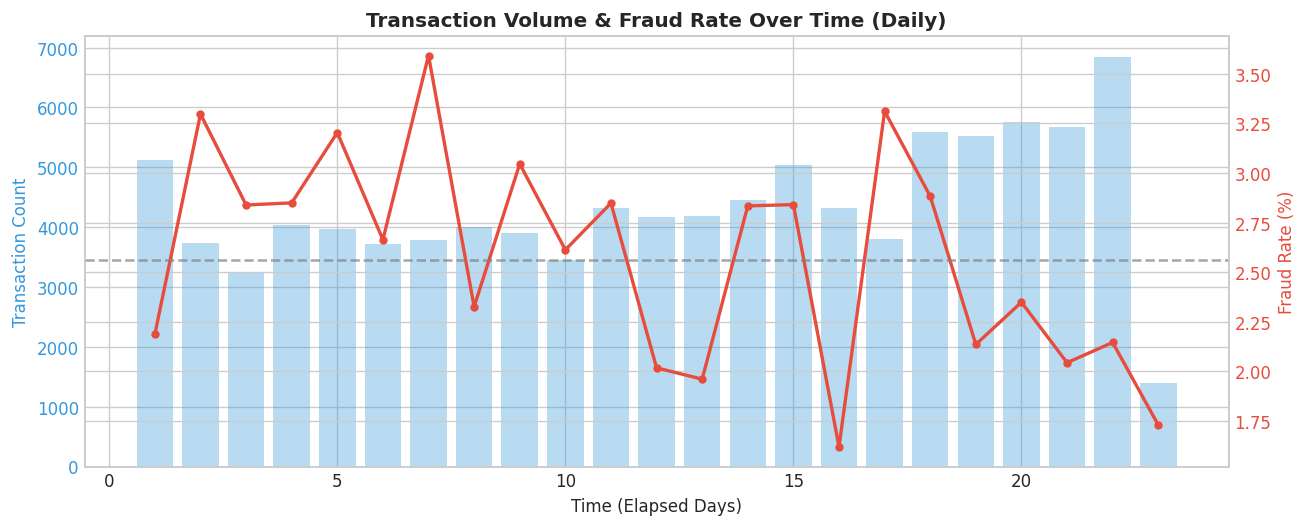

In [4]:
df["Day"] = (df[time_col] // 86400).astype(int)
daily_stats = df.groupby("Day")[target_col].agg(["count", "mean"]).reset_index()
daily_stats["fraud_pct"] = daily_stats["mean"] * 100

fig, ax1 = plt.subplots(figsize=(11, 4.5))

color = "#3498db"
ax1.set_xlabel("Time (Elapsed Days)")
ax1.set_ylabel("Transaction Count", color=color)
ax1.bar(daily_stats["Day"], daily_stats["count"], alpha=0.35, color=color, label="Volume")
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "#e74c3c"
ax2.set_ylabel("Fraud Rate (%)", color=color)
ax2.plot(daily_stats["Day"], daily_stats["fraud_pct"], color=color, linewidth=2, marker="o", markersize=4, label="Fraud Rate %")
ax2.axhline(y=df[target_col].mean() * 100, color="gray", linestyle="--", alpha=0.7, label="Mean Fraud Rate")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Transaction Volume & Fraud Rate Over Time (Daily)", fontweight="bold")
fig.tight_layout()
plt.savefig(FIG_DIR / "02_temporal_fraud_drift.png")
plt.show()


**5. Missing-Value Analysis**

We assess feature-level missingness across the dataset. The identity table is left-joined and only present for a subset of transactions, creating structured missingness that the neural network must handle natively.


=== Features by Missingness Tier ===
  0% (Complete)       :  78 features (17.9%)
  1% - 20%            :  38 features (8.7%)
  20% - 50%           :  87 features (20.0%)
  50% - 75%           : 207 features (47.6%)
  > 75% Extreme       :  25 features (5.7%)


C:\Users\mst\AppData\Local\Temp\ipykernel_20088\2261547728.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_summary.index, y=tier_summary.values, palette="Blues_r", ax=axes[0])
C:\Users\mst\AppData\Local\Temp\ipykernel_20088\2261547728.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)
C:\Users\mst\AppData\Local\Temp\ipykernel_20088\2261547728.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, y="Feature", x="Missing_Pct", palette="rocket", ax=axes[1])


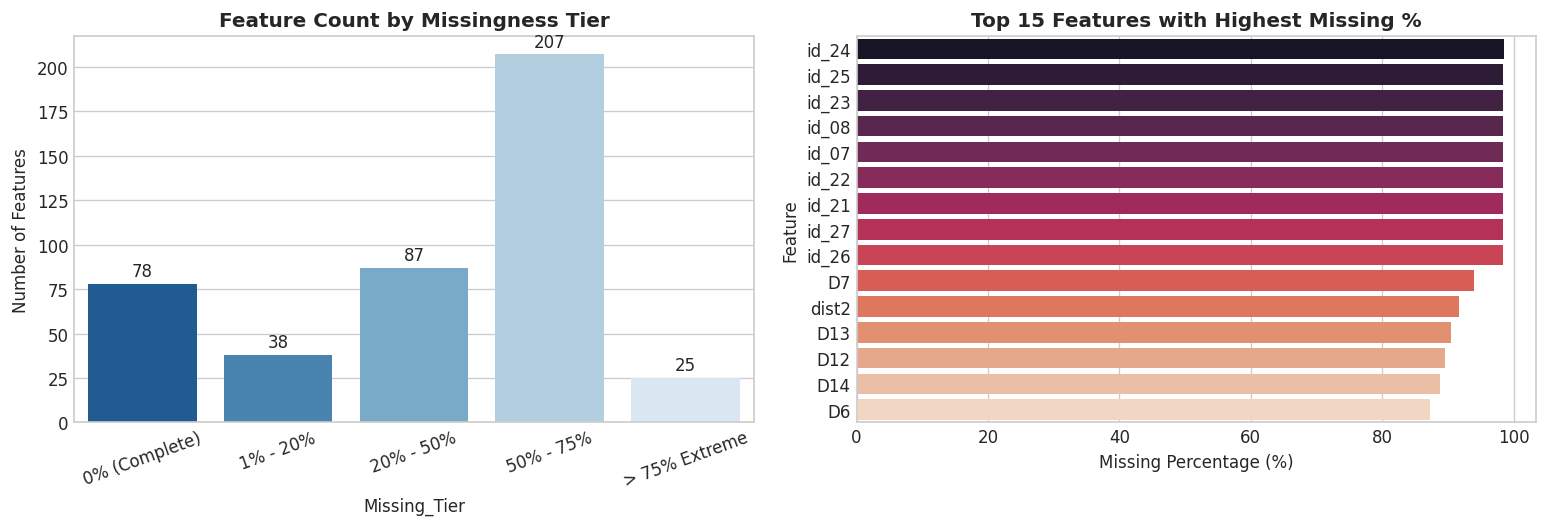

In [5]:
missing_profile = compute_missing_and_cardinality(df)

bins = [-1, 0, 20, 50, 75, 100]
labels = ["0% (Complete)", "1% - 20%", "20% - 50%", "50% - 75%", "> 75% Extreme"]
missing_profile["Missing_Tier"] = pd.cut(missing_profile["Missing_Pct"], bins=bins, labels=labels)
tier_summary = missing_profile["Missing_Tier"].value_counts().reindex(labels)

print("=== Features by Missingness Tier ===")
for tier, count in tier_summary.items():
    print(f"  {tier:20s}: {count:3d} features ({count/len(missing_profile)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=tier_summary.index, y=tier_summary.values, palette="Blues_r", ax=axes[0])
axes[0].set_title("Feature Count by Missingness Tier", fontweight="bold")
axes[0].set_ylabel("Number of Features")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2., p.get_height() + 2),
                     ha="center", va="bottom", fontsize=10)

top_missing = missing_profile.head(15)
sns.barplot(data=top_missing, y="Feature", x="Missing_Pct", palette="rocket", ax=axes[1])
axes[1].set_title("Top 15 Features with Highest Missing %", fontweight="bold")
axes[1].set_xlabel("Missing Percentage (%)")

plt.tight_layout()
plt.savefig(FIG_DIR / "03_missingness_summary.png")
plt.show()


**6. Categorical Analysis**

We evaluate the cardinality of all 49 categorical variables. For high-cardinality features (such as `card1` and `DeviceInfo`), we inspect the proportion of singleton and rare categories to define our vocabulary thresholding strategy for PyTorch embeddings.


=== Top 15 Categorical Features by Cardinality ===
   Feature  Unique_Values  Missing_Pct            Tier
     card1           7677         0.00     High (>100)
DeviceInfo            866        63.53     High (>100)
     card2            499         1.35     High (>100)
     id_19            445        60.13     High (>100)
     id_21            277        98.38     High (>100)
     addr1            264         9.04     High (>100)
     id_20            225        60.13     High (>100)
     id_25            213        98.39     High (>100)
     id_33            132        72.44     High (>100)
     card5             87         0.53 Medium (11-100)
     id_31             82        59.76 Medium (11-100)
     card3             74         0.00 Medium (11-100)
     id_17             70        60.12 Medium (11-100)
     id_30             67        70.16 Medium (11-100)
     id_26             63        98.38 Medium (11-100)

Entity Cardinality Analysis for 'card1':
  Total Unique Entities: 7,

C:\Users\mst\AppData\Local\Temp\ipykernel_20088\3252919717.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_profile.head(12), x="Unique_Values", y="Feature", palette="viridis")


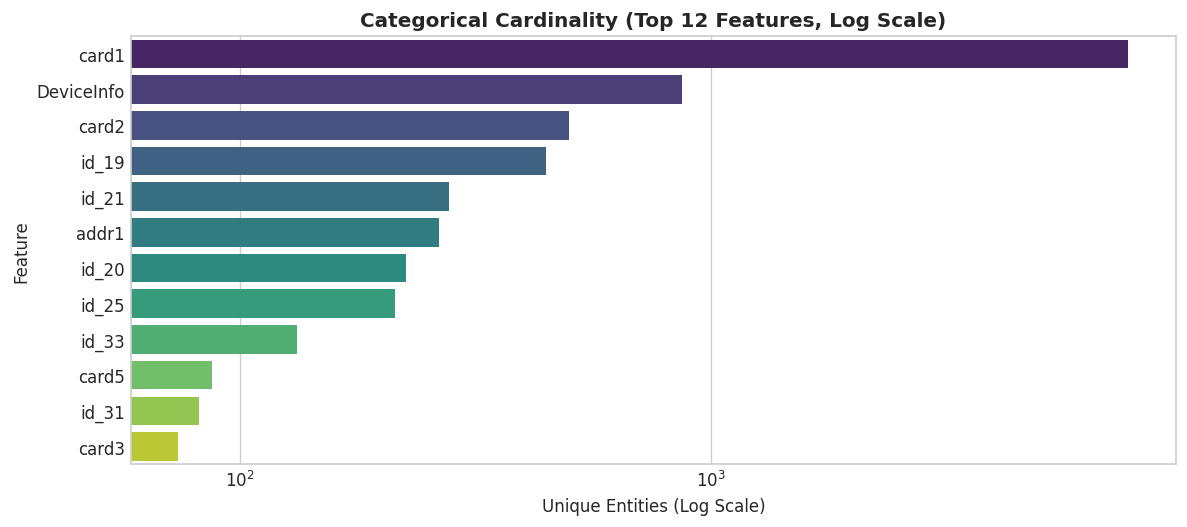

In [6]:
cat_profile = missing_profile[missing_profile["Feature"].isin(cat_cols)].sort_values("Unique_Values", ascending=False)

def categorize_cardinality(n):
    if n <= 10:
        return "Low (<=10)"
    elif n <= 100:
        return "Medium (11-100)"
    else:
        return "High (>100)"

cat_profile["Tier"] = cat_profile["Unique_Values"].apply(categorize_cardinality)

print("=== Top 15 Categorical Features by Cardinality ===")
print(cat_profile[["Feature", "Unique_Values", "Missing_Pct", "Tier"]].head(15).to_string(index=False))

# Rare category analysis for card1
card1_counts = df["card1"].value_counts()
singletons = (card1_counts == 1).sum()
rare_10 = (card1_counts < 10).sum()
print(f"\nEntity Cardinality Analysis for 'card1':")
print(f"  Total Unique Entities: {len(card1_counts):,}")
print(f"  Singletons (freq = 1): {singletons:,} ({singletons/len(card1_counts)*100:.1f}%)")
print(f"  Rare (freq < 10):     {rare_10:,} ({rare_10/len(card1_counts)*100:.1f}%)")

plt.figure(figsize=(10, 4.5))
sns.barplot(data=cat_profile.head(12), x="Unique_Values", y="Feature", palette="viridis")
plt.xscale("log")
plt.title("Categorical Cardinality (Top 12 Features, Log Scale)", fontweight="bold")
plt.xlabel("Unique Entities (Log Scale)")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_cardinality_log.png")
plt.show()


**7. Numerical Analysis**

We inspect the distributions, skewness, and extreme outliers of numerical attributes, specifically `TransactionAmt`. We also detect zero-variance or near-constant features that provide no signal.


=== Transaction Amount Percentiles ===
count    100000.000000
mean        130.743347
std         206.024689
min           0.292000
25%          45.000000
50%          75.000000
75%         135.949997
90%         255.000000
99%        1000.000000
99.9%      2547.459971
max        4829.950195
Name: TransactionAmt, dtype: float64


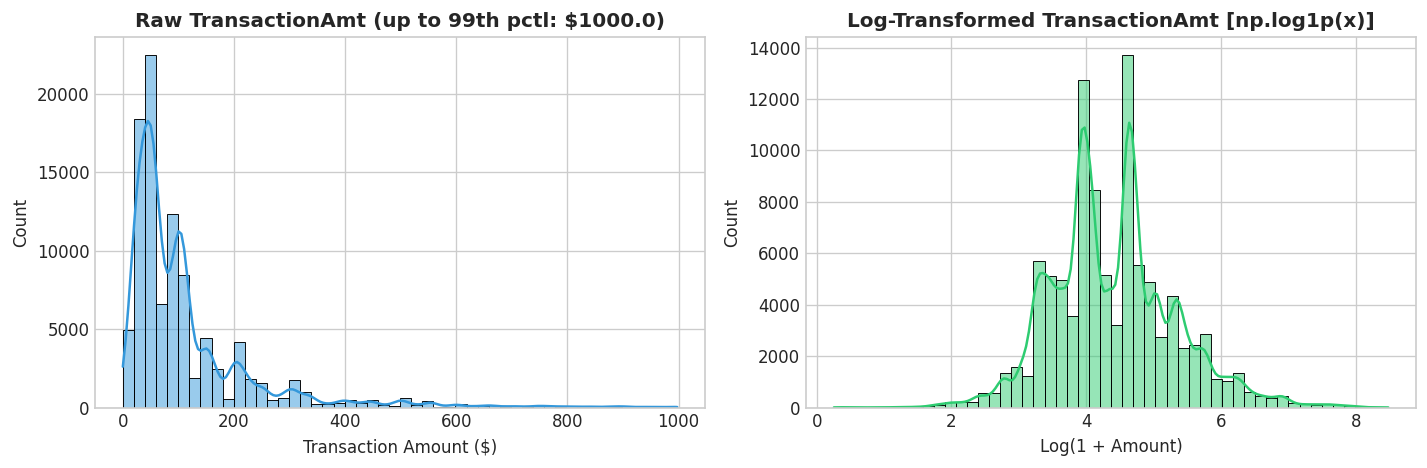


Zero-variance numerical features identified: 1 (['V107'])


In [7]:
amt = df["TransactionAmt"]
amt_stats = amt.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.99, 0.999])
print("=== Transaction Amount Percentiles ===")
print(amt_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(amt[amt < amt.quantile(0.99)], bins=50, kde=True, color="#3498db", ax=axes[0])
axes[0].set_title(f"Raw TransactionAmt (up to 99th pctl: ${amt.quantile(0.99):.1f})", fontweight="bold")
axes[0].set_xlabel("Transaction Amount ($)")

sns.histplot(np.log1p(amt), bins=50, kde=True, color="#2ecc71", ax=axes[1])
axes[1].set_title("Log-Transformed TransactionAmt [np.log1p(x)]", fontweight="bold")
axes[1].set_xlabel("Log(1 + Amount)")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_amt_transformation.png")
plt.show()

# Detect zero-variance features
num_std = df[num_cols].std()
zero_std = num_std[num_std == 0].index.tolist()
print(f"\nZero-variance numerical features identified: {len(zero_std)} ({zero_std})")


**8. Fraud-Specific Patterns**

We analyze bivariate correlations between fraud probability and key domain variables:
- `ProductCD` (Product code)
- `card4` (Card brand / network)
- `card6` (Card type: credit vs debit)
- `DeviceType` (Mobile vs Desktop)
- `P_emaildomain` (Purchaser email domain)


C:\Users\mst\AppData\Local\Temp\ipykernel_20088\413546761.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pcd_stats.sort_values("fraud_pct", ascending=False), x="ProductCD", y="fraud_pct", palette="magma", ax=axes[0, 0])
C:\Users\mst\AppData\Local\Temp\ipykernel_20088\413546761.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=card4_stats.sort_values("fraud_pct", ascending=False), x="card4", y="fraud_pct", palette="coolwarm", ax=axes[0, 1])
C:\Users\mst\AppData\Local\Temp\ipykernel_20088\413546761.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sa

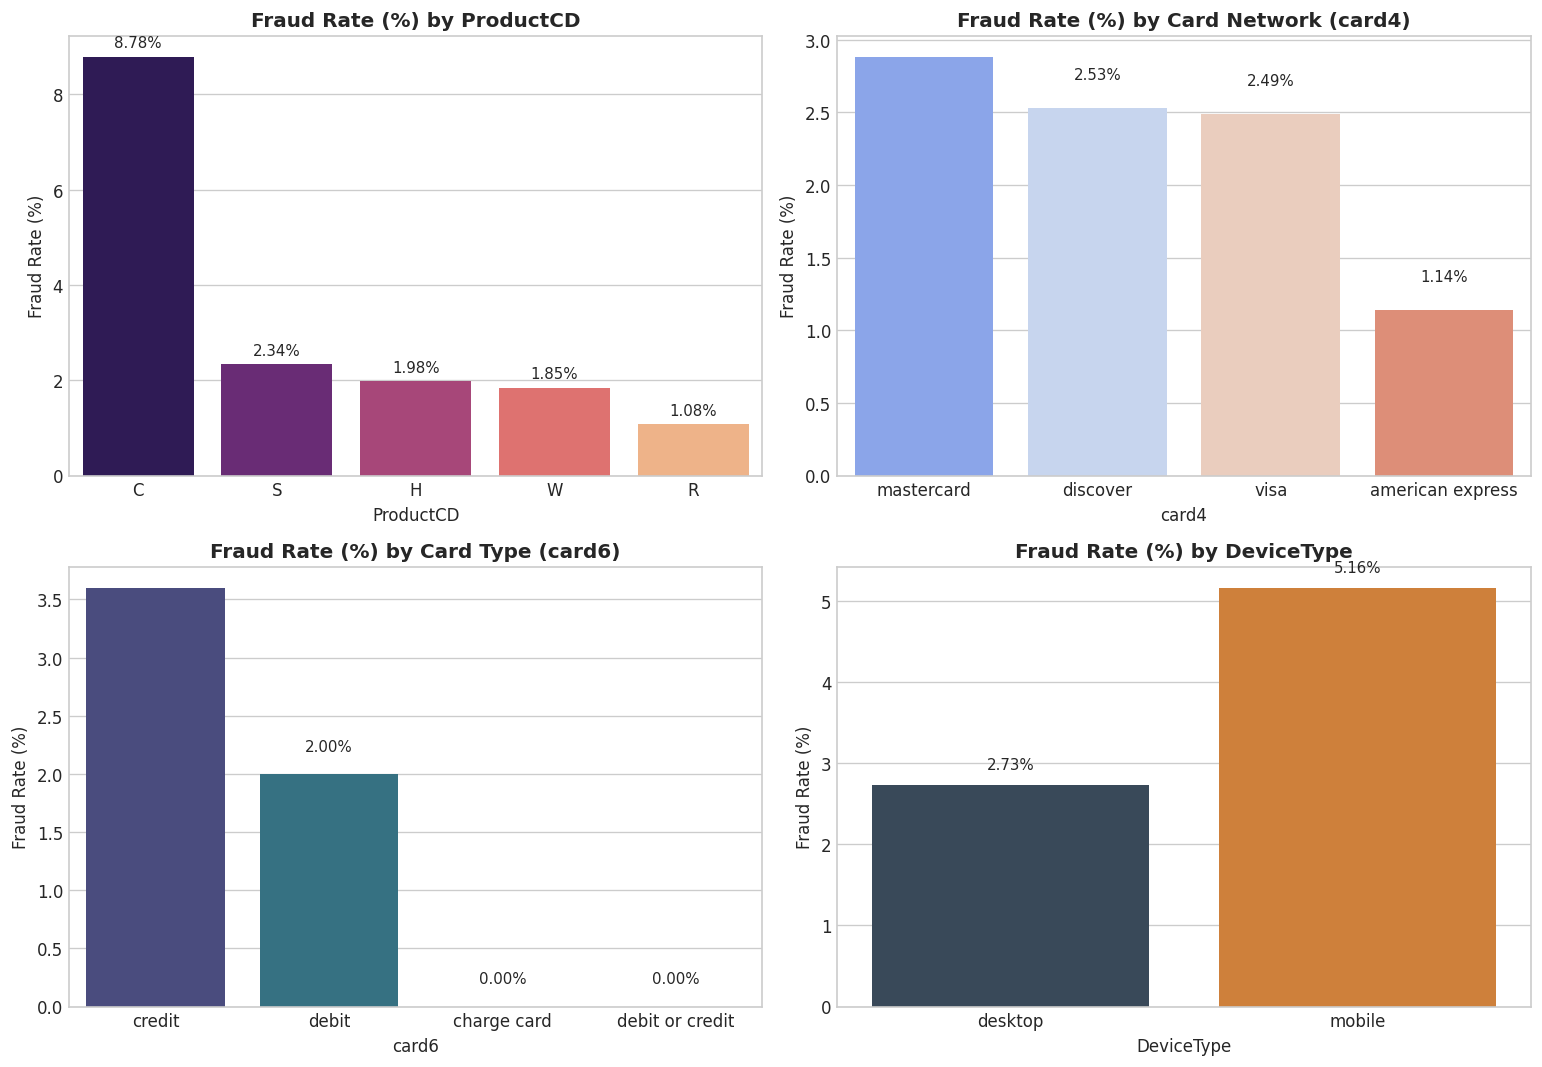

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. ProductCD
pcd_stats = df.groupby("ProductCD")[target_col].agg(["count", "mean"]).reset_index()
pcd_stats["fraud_pct"] = pcd_stats["mean"] * 100
sns.barplot(data=pcd_stats.sort_values("fraud_pct", ascending=False), x="ProductCD", y="fraud_pct", palette="magma", ax=axes[0, 0])
axes[0, 0].set_title("Fraud Rate (%) by ProductCD", fontweight="bold")
axes[0, 0].set_ylabel("Fraud Rate (%)")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height() + 0.2), ha="center", fontsize=9)

# 2. Card Network (card4)
card4_stats = df.groupby("card4")[target_col].agg(["count", "mean"]).reset_index()
card4_stats["fraud_pct"] = card4_stats["mean"] * 100
sns.barplot(data=card4_stats.sort_values("fraud_pct", ascending=False), x="card4", y="fraud_pct", palette="coolwarm", ax=axes[0, 1])
axes[0, 1].set_title("Fraud Rate (%) by Card Network (card4)", fontweight="bold")
axes[0, 1].set_ylabel("Fraud Rate (%)")
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height() + 0.2), ha="center", fontsize=9)

# 3. Card Type (card6)
card6_stats = df.groupby("card6")[target_col].agg(["count", "mean"]).reset_index()
card6_stats["fraud_pct"] = card6_stats["mean"] * 100
sns.barplot(data=card6_stats.sort_values("fraud_pct", ascending=False), x="card6", y="fraud_pct", palette="viridis", ax=axes[1, 0])
axes[1, 0].set_title("Fraud Rate (%) by Card Type (card6)", fontweight="bold")
axes[1, 0].set_ylabel("Fraud Rate (%)")
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height() + 0.2), ha="center", fontsize=9)

# 4. DeviceType
device_stats = df.dropna(subset=["DeviceType"]).groupby("DeviceType")[target_col].agg(["count", "mean"]).reset_index()
device_stats["fraud_pct"] = device_stats["mean"] * 100
sns.barplot(data=device_stats, x="DeviceType", y="fraud_pct", palette=["#34495e", "#e67e22"], ax=axes[1, 1])
axes[1, 1].set_title("Fraud Rate (%) by DeviceType", fontweight="bold")
axes[1, 1].set_ylabel("Fraud Rate (%)")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height() + 0.2), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "06_fraud_patterns_grid.png")
plt.show()


**9. Leakage Investigation**

We audit the dataset to ensure strict leakage prevention:
1. **Identifier Exclusion**: `TransactionID` is confirmed as a non-predictive sequential identifier and must be excluded from feature vectors.
2. **Post-Event Variables**: Verifying that no post-hoc resolution codes exist in features.
3. **Temporal Lookahead Prevention**: Models must not access future transaction states; scalers and categorical frequency tables must only be fit on training records.


In [9]:
# Verify absence of post-hoc chargeback columns
forbidden_leakage_terms = ["target", "label", "chargeback", "status", "outcome"]
suspicious_cols = [c for c in df.columns if any(term in c.lower() for term in forbidden_leakage_terms) and c != target_col]
print(f"Suspicious columns containing target-like names: {suspicious_cols} (Expected: None)")

# Confirm TransactionID is unique and strictly an identifier
print(f"TransactionID unique: {df[id_col].nunique() == len(df)}")


Suspicious columns containing target-like names: [] (Expected: None)
TransactionID unique: True


**10. Train / Validation / Test Verification**

We execute the strict chronological split (70% Train, 15% Val, 15% Test) and verify timestamp ordering, absence of lookahead leakage, and split properties.


In [10]:
train_split, val_split, test_split = temporal_train_val_test_split(df, val_ratio=0.15, test_ratio=0.15)

train_max_t = train_split[time_col].max()
val_min_t = val_split[time_col].min()
val_max_t = val_split[time_col].max()
test_min_t = test_split[time_col].min()

print("=== Temporal Integrity Verification ===")
print(f"Train DT Max: {train_max_t:,} < Val DT Min: {val_min_t:,} -> {train_max_t < val_min_t}")
print(f"Val DT Max:   {val_max_t:,} < Test DT Min: {test_min_t:,} -> {val_max_t < test_min_t}")

assert train_max_t < val_min_t, "Contamination: Train and Val timestamps overlap!"
assert val_max_t < test_min_t, "Contamination: Val and Test timestamps overlap!"
print("=> Strict chronological boundaries verified. No temporal leakage.")


2026-09-30 23:10:53,601 - INFO - Sorting dataset by 'TransactionDT' for strict chronological temporal splitting...
2026-09-30 23:10:54,014 - INFO - Temporal Split Completed Successfully:
2026-09-30 23:10:54,016 - INFO -   [TRAIN] Rows: 70,000 (70.0%) | DT: [86,400 - 1,564,844] (~17.1 days), Frauds=1879 (2.68%)
2026-09-30 23:10:54,017 - INFO -   [VAL] Rows: 15,000 (15.0%) | DT: [1,564,850 - 1,804,023] (~2.8 days), Frauds=377 (2.51%)
2026-09-30 23:10:54,018 - INFO -   [TEST] Rows: 15,000 (15.0%) | DT: [1,804,027 - 2,006,364] (~2.3 days), Frauds=305 (2.03%)


=== Temporal Integrity Verification ===
Train DT Max: 1,564,844 < Val DT Min: 1,564,850 -> True
Val DT Max:   1,804,023 < Test DT Min: 1,804,027 -> True
=> Strict chronological boundaries verified. No temporal leakage.


**11. EDA Conclusions & Next-Phase Roadmap**

From the empirical analysis, we establish the following concrete specifications for Phase 3:

| Analytical Finding | Concrete Preprocessing Decision |
| :--- | :--- |
| **Severe Imbalance (~3.5% fraud)** | Use `pos_weight ≈ 28–38` in PyTorch `BCEWithLogitsLoss` and Focal Loss. Primary metric: **PR-AUC**. |
| **Heavy Skew in `TransactionAmt`** | Apply `np.log1p` transformation followed by `StandardScaler`. |
| **High Cardinality (`card1`, `DeviceInfo`)** | Apply frequency thresholding (keep entities with $\ge 10$ occurrences in Train, map remainder to index `0` `<UNK>`). |
| **Low/Medium Cardinalities (`ProductCD`, etc.)** | Integer-encode for PyTorch `nn.Embedding`, reserving index `0` for `<MISSING>`. |
| **Identity Missingness (~76%)** | Retain missingness as an informative token for embeddings; apply median imputation on numericals. |
| **Temporal Non-Stationarity** | Preserve strict chronological splitting to evaluate models against future transaction distribution shifts. |
